# Тематическое моделирование LDA

Представим рецепты как bag of ingredients, выделим скрытые темы и сравним распределение тем с известными типами кухни.

In [1]:
import json
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

sns.set_theme(style="whitegrid")

In [2]:
with open("recipes.json", encoding="utf-8") as file:
    recipes = json.load(file)

data = pd.DataFrame(recipes)
data["document"] = data["ingredients"].map(lambda ingredients: " ".join(item.replace(" ", "_") for item in ingredients))
display(data.head())
display(data["cuisine"].value_counts().to_frame("recipes"))

,cuisine,ingredients,document
0,italian,"[tomato, basil, olive oil, garlic, pasta]",tomato basil olive_oil garlic pasta
1,italian,"[parmesan, risotto rice, mushroom, butter, onion]",parmesan risotto_rice mushroom butter onion
2,italian,"[mozzarella, tomato, basil, flour, olive oil]",mozzarella tomato basil flour olive_oil
3,italian,"[pasta, egg, parmesan, bacon, black pepper]",pasta egg parmesan bacon black_pepper
4,italian,"[tomato, oregano, garlic, beef, pasta]",tomato oregano garlic beef pasta


,recipes
cuisine,
italian,5
mexican,5
indian,5
japanese,5
french,5


## Обучение LDA

In [3]:
vectorizer = CountVectorizer(binary=True)
matrix = vectorizer.fit_transform(data["document"])
lda = LatentDirichletAllocation(n_components=5, learning_method="batch", max_iter=100, random_state=42)
document_topics = lda.fit_transform(matrix)
terms = vectorizer.get_feature_names_out()

topic_rows = []
for topic_index, weights in enumerate(lda.components_):
    top_terms = terms[weights.argsort()[-8:][::-1]]
    topic_rows.append({"topic": f"topic_{topic_index}", "top_ingredients": ", ".join(top_terms)})

pd.DataFrame(topic_rows)

,topic,top_ingredients
0,topic_0,"tomato, cream, flour, olive_oil, basil, turmer..."
1,topic_1,"butter, pasta, egg, beef, parmesan, mushroom, ..."
2,topic_2,"chili, beans, onion, lime, corn_tortilla, avoc..."
3,topic_3,"soy_sauce, rice, green_onion, nori, garlic, se..."
4,topic_4,"chicken, cumin, onion, ginger, rice, garlic, s..."


## Темы документов

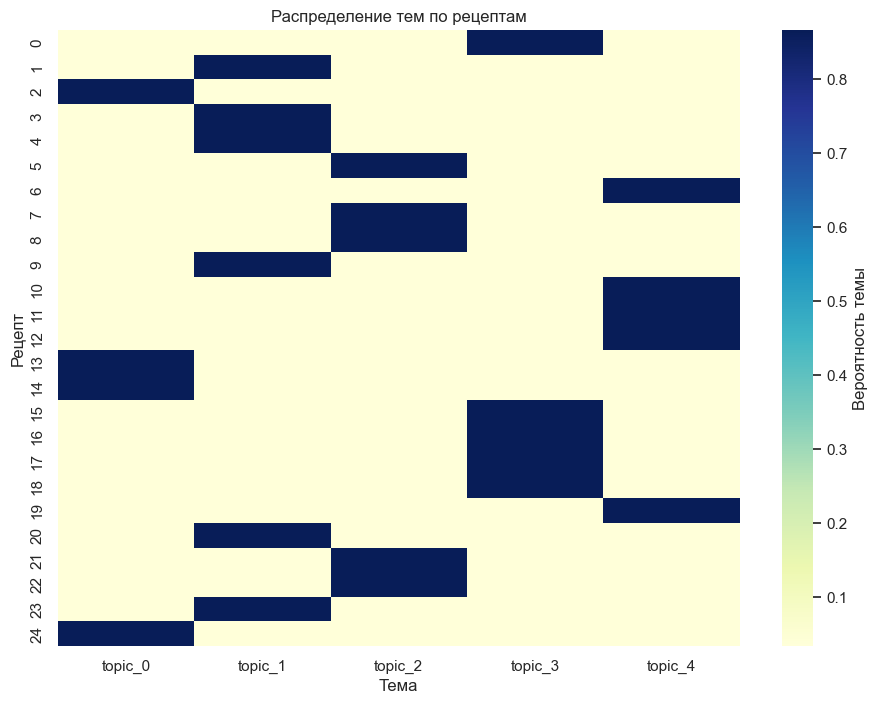

In [4]:
topic_frame = pd.DataFrame(document_topics, columns=[f"topic_{index}" for index in range(5)])
topic_frame["cuisine"] = data["cuisine"]

plt.figure(figsize=(11, 8))
sns.heatmap(topic_frame.drop(columns="cuisine"), cmap="YlGnBu", cbar_kws={"label": "Вероятность темы"})
plt.title("Распределение тем по рецептам")
plt.xlabel("Тема")
plt.ylabel("Рецепт")
plt.show()

## Связь тем с кухнями

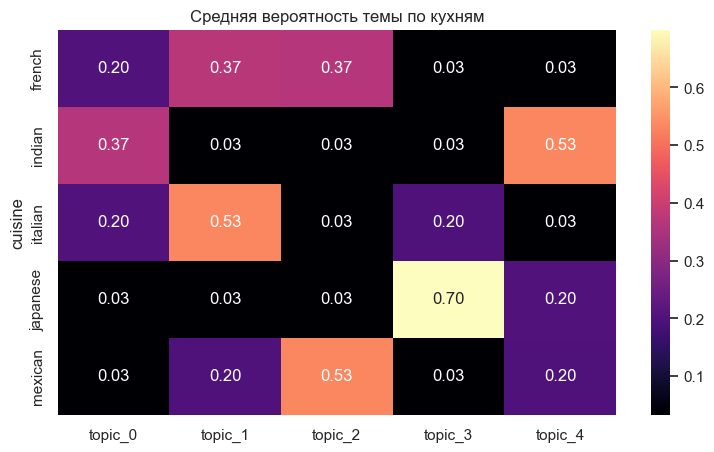

,topic_0,topic_1,topic_2,topic_3,topic_4
cuisine,,,,,
french,0.200128,0.366631,0.366267,0.033393,0.033581
indian,0.366237,0.033555,0.033624,0.033425,0.533160
italian,0.200200,0.532946,0.033588,0.199711,0.033555
japanese,0.033368,0.033419,0.033347,0.699869,0.199997
mexican,0.033715,0.199786,0.533140,0.033410,0.199948


In [5]:
cuisine_topics = topic_frame.groupby("cuisine").mean()

plt.figure(figsize=(9, 5))
sns.heatmap(cuisine_topics, annot=True, fmt=".2f", cmap="magma")
plt.title("Средняя вероятность темы по кухням")
plt.show()

cuisine_topics

## Вывод

LDA находит совместно встречающиеся ингредиенты без использования целевых меток. Темы можно интерпретировать по словам с наибольшими весами, но качество зависит от корпуса, словаря и выбранного числа тем.